# Phase 2.8 — Event Timeline Visualizations

Complete temporal context for key anomaly events — showing the full time-series with training period, prediction window, event boundaries, and operational status changes.

These visualizations give a "big picture" view of each fault: when did the turbine start behaving abnormally, when did it go into downtime, and how long did the event last? The status strip is especially important — it shows the physical manifestation of each fault as the turbine transitions from Normal (green) to Downtime (red).

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

# Project path setup
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)

from src.data.load_data import load_event, load_event_info, get_event_ids
from src.features.thermal_config import get_sensors, SUBSYSTEM_SENSORS

# Load unified event catalog
event_info = load_event_info()
print(f"Loaded {len(event_info)} events from unified catalog")
print(f"Anomaly events: {len(event_info[event_info['event_label'] == 'anomaly'])}")
print(f"Farms: {sorted(event_info['farm'].unique())}")

# Human-readable sensor descriptions (hardcoded from feature_description.csv)
SENSOR_LABELS = {
    # Farm A
    "sensor_11_avg": "Gearbox HSS Bearing Temp",
    "sensor_12_avg": "Gearbox Oil Temp",
    "sensor_13_avg": "Generator Bearing 2 (DE)",
    "sensor_14_avg": "Generator Bearing 1 (NDE)",
    "sensor_15_avg": "Stator Winding Phase 1",
    "sensor_16_avg": "Stator Winding Phase 2",
    "sensor_17_avg": "Stator Winding Phase 3",
    "sensor_38_avg": "HV Transformer L1",
    "sensor_39_avg": "HV Transformer L2",
    "sensor_40_avg": "HV Transformer L3",
    "sensor_41_avg": "Hydraulic Oil Temp",
    "sensor_8_avg": "VCS Choke Coil Temp",
    "sensor_9_avg": "VCP Board Temp",
    "sensor_10_avg": "VCS Cooling Water Temp",
    # Farm B
    "sensor_34_avg": "Gearbox Bearing 1",
    "sensor_35_avg": "Gearbox Bearing 2",
    "sensor_36_avg": "Gearbox Bearing 3",
    "sensor_37_avg": "Gearbox Bearing 4",
    "sensor_38_avg": "Gearbox Oil Inlet",
    "sensor_39_avg": "Gearbox Oil Tank",
    "sensor_32_avg": "Generator Bearing 1",
    "sensor_33_avg": "Generator Bearing 2",
    "sensor_51_avg": "Rotor Bearing 1",
    "sensor_52_avg": "Rotor Bearing 2",
    "sensor_53_avg": "Slip Ring Temp",
    "sensor_31_avg": "Internal Consumption Xfmr",
    "sensor_40_avg": "Transformer Core",
    "sensor_41_avg": "Transformer L1 (MV)",
    "sensor_42_avg": "Transformer L1 (LV)",
    "sensor_43_avg": "Transformer L2 (MV)",
    "sensor_44_avg": "Transformer L2 (LV)",
    "sensor_45_avg": "Transformer L3 (MV)",
    "sensor_46_avg": "Transformer L3 (LV)",
    "sensor_47_avg": "Transformer Cell Temp",
    # Farm C
    "sensor_151_avg": "Planetary Bearing A1",
    "sensor_152_avg": "Planetary Bearing A2",
    "sensor_178_avg": "Hydraulic Oil Tank 1",
    "sensor_179_avg": "Hydraulic Oil Tank 2",
    "sensor_167_avg": "Air Temp Transformer Container",
    "sensor_188_avg": "Oil Temp EB Transformer",
    "sensor_191_avg": "Oil Temp Main Transformer 1",
    "sensor_192_avg": "Oil Temp Main Transformer 2",
    "sensor_46_avg": "Water Temp Flow TT1",
    "sensor_175_avg": "Axis 3 Cooling Element",
    "sensor_176_avg": "Cooling Air Exit Temp",
    "sensor_208_avg": "Axis 1 Cooling Element",
    "sensor_209_avg": "Axis 2 Cooling Element",
    "sensor_228_avg": "Cooling Sensor 228",
    "sensor_229_avg": "Cooling Sensor 229",
    "sensor_233_avg": "Cooling Sensor 233",
    "sensor_234_avg": "Cooling Sensor 234",
}

def get_sensor_label(sensor_col):
    """Return human-readable label for a sensor column, or clean up the raw name."""
    if sensor_col in SENSOR_LABELS:
        return SENSOR_LABELS[sensor_col]
    # Fallback: capitalize sensor name
    return sensor_col.replace("_avg", "").replace("_", " ").title()

print("\nSetup complete.")

Loaded 95 events from unified catalog
Anomaly events: 45
Farms: ['A', 'B', 'C']

Setup complete.


In [2]:
# ---------------------------------------------------------------------------
# Reusable timeline plotting function
# ---------------------------------------------------------------------------

# Status type color map
STATUS_COLORS = {
    0: "#2ecc71",   # Normal — green
    1: "#f1c40f",   # Derated — yellow
    2: "#00bcd4",   # Idling — cyan
    3: "#9b59b6",   # Service — purple
    4: "#e74c3c",   # Downtime — red
    5: "#95a5a6",   # Other — gray
}
STATUS_LABELS = {
    0: "Normal",
    1: "Derated",
    2: "Idling",
    3: "Service",
    4: "Downtime",
    5: "Other",
}

# Sensor line colors (up to 6 sensors)
SENSOR_COLORS = ["#2980b9", "#e67e22", "#27ae60", "#e74c3c", "#8e44ad", "#1abc9c"]


def plot_event_timeline(farm, event_id, sensors, title=None, save_path=None):
    """
    Multi-panel event timeline visualization.
    
    Parameters
    ----------
    farm : str — "A", "B", or "C"
    event_id : int — event ID
    sensors : list[str] — sensor columns to plot (2-4 recommended)
    title : str or None — override figure title
    save_path : str or None — if set, save figure to this path
    
    Returns
    -------
    matplotlib Figure
    """
    # Load data
    df = load_event(farm, event_id)
    meta = event_info[(event_info["farm"] == farm.upper()) & (event_info["event_id"] == event_id)]
    if len(meta) == 0:
        raise ValueError(f"No event info for Farm {farm} event {event_id}")
    meta = meta.iloc[0]
    
    event_start_id = int(meta["event_start_id"])
    event_end_id = int(meta["event_end_id"])
    event_desc = meta["event_description"]
    event_start_ts = meta["event_start"]
    event_end_ts = meta["event_end"]
    
    # Compute event duration in days
    try:
        duration_days = (pd.Timestamp(event_end_ts) - pd.Timestamp(event_start_ts)).days
    except Exception:
        duration_days = "?"
    
    # Find train/prediction boundary index
    train_mask = df["train_test"] == "train"
    boundary_idx = train_mask.sum()  # first prediction row index
    
    # Filter sensors to those that actually exist in the dataset
    valid_sensors = [s for s in sensors if s in df.columns]
    if not valid_sensors:
        print(f"  WARNING: No valid sensors found for Farm {farm} event {event_id}")
        return None
    
    # Primary sensor for rolling std
    primary_sensor = valid_sensors[0]
    
    # Rolling std (window ~ 1 day = 144 ten-minute intervals)
    rolling_std = df[primary_sensor].rolling(window=144, min_periods=72).std()
    
    # Build x-axis: row index
    x = np.arange(len(df))
    
    # Approximate days from start (10-min intervals)
    days_from_start = x / 144.0
    
    # ---- Figure setup ----
    fig, axes = plt.subplots(3, 1, figsize=(16, 10), 
                              gridspec_kw={"height_ratios": [4, 1, 2]},
                              sharex=True)
    fig.subplots_adjust(hspace=0.08)
    
    if title is None:
        title = f"Farm {farm} — Event {event_id}: {event_desc}"
    fig.suptitle(title, fontsize=14, fontweight="bold", y=0.98)
    
    # =====================================================================
    # TOP PANEL: Thermal sensor time-series
    # =====================================================================
    ax_top = axes[0]
    for i, sensor in enumerate(valid_sensors):
        color = SENSOR_COLORS[i % len(SENSOR_COLORS)]
        label = get_sensor_label(sensor)
        ax_top.plot(x, df[sensor], color=color, linewidth=0.6, alpha=0.85, label=label)
    
    ax_top.set_ylabel("Temperature (°C)", fontsize=10)
    ax_top.legend(loc="upper left", fontsize=8, framealpha=0.9, ncol=2)
    ax_top.grid(True, alpha=0.3, linewidth=0.5)
    ax_top.set_title("Thermal Sensors", fontsize=10, loc="left", style="italic", pad=4)
    
    # =====================================================================
    # MIDDLE PANEL: Status type colored strip
    # =====================================================================
    ax_mid = axes[1]
    
    # Build colored bar segments from status_type_id
    status = df["status_type_id"].values
    # Find contiguous segments
    segments = []
    seg_start = 0
    for i in range(1, len(status)):
        if status[i] != status[seg_start]:
            segments.append((seg_start, i - seg_start, status[seg_start]))
            seg_start = i
    segments.append((seg_start, len(status) - seg_start, status[seg_start]))
    
    for seg_x, seg_w, seg_status in segments:
        color = STATUS_COLORS.get(int(seg_status), "#95a5a6")
        ax_mid.barh(0, seg_w, left=seg_x, height=1.0, color=color, edgecolor="none")
    
    ax_mid.set_ylim(-0.5, 0.5)
    ax_mid.set_yticks([])
    ax_mid.set_ylabel("Status", fontsize=10)
    
    # Status legend
    present_statuses = sorted(set(int(s) for s in df["status_type_id"].unique()))
    status_patches = [mpatches.Patch(color=STATUS_COLORS.get(s, "#95a5a6"), 
                                      label=STATUS_LABELS.get(s, f"Unknown ({s})"))
                      for s in present_statuses]
    ax_mid.legend(handles=status_patches, loc="upper left", fontsize=7, 
                  framealpha=0.9, ncol=len(present_statuses))
    
    # =====================================================================
    # BOTTOM PANEL: Rolling std of primary sensor (volatility)
    # =====================================================================
    ax_bot = axes[2]
    ax_bot.fill_between(x, 0, rolling_std, color="#3498db", alpha=0.4)
    ax_bot.plot(x, rolling_std, color="#2980b9", linewidth=0.7, alpha=0.8)
    ax_bot.set_ylabel(f"Rolling Std\n({get_sensor_label(primary_sensor)})", fontsize=9)
    ax_bot.set_xlabel("Row Index", fontsize=10)
    ax_bot.grid(True, alpha=0.3, linewidth=0.5)
    ax_bot.set_title("Volatility (1-day rolling std)", fontsize=10, loc="left", style="italic", pad=4)
    
    # =====================================================================
    # ANNOTATIONS on all panels
    # =====================================================================
    for ax in axes:
        # Train/Prediction boundary
        ax.axvline(boundary_idx, color="#2c3e50", linestyle="--", linewidth=1.2, alpha=0.8)
        
        # Event window shading
        # Convert event_start_id and event_end_id to row indices
        # These IDs correspond to the 'id' column in the dataset
        if "id" in df.columns:
            start_rows = df.index[df["id"] == event_start_id]
            end_rows = df.index[df["id"] == event_end_id]
            if len(start_rows) > 0 and len(end_rows) > 0:
                ev_start_row = start_rows[0]
                ev_end_row = end_rows[0]
            else:
                # Fallback: use event_start_id/event_end_id directly if they look like indices
                ev_start_row = max(0, event_start_id - df["id"].iloc[0]) if "id" in df.columns else event_start_id
                ev_end_row = min(len(df) - 1, event_end_id - df["id"].iloc[0]) if "id" in df.columns else event_end_id
        else:
            ev_start_row = event_start_id
            ev_end_row = min(event_end_id, len(df) - 1)
        
        ax.axvspan(ev_start_row, ev_end_row, color="red", alpha=0.12, zorder=0)
    
    # Text annotation for event description and boundary label (top panel only)
    ax_top.text(boundary_idx, ax_top.get_ylim()[1], "  Train | Prediction ",
                fontsize=8, color="#2c3e50", fontweight="bold",
                verticalalignment="top", horizontalalignment="center",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", 
                          edgecolor="#2c3e50", alpha=0.85))
    
    # Event description annotation in the event window
    ev_mid = (ev_start_row + ev_end_row) / 2
    ypos = ax_top.get_ylim()[0] + 0.75 * (ax_top.get_ylim()[1] - ax_top.get_ylim()[0])
    event_text = f"{event_desc}\n({duration_days} days)"
    ax_top.annotate(event_text, xy=(ev_mid, ypos),
                    fontsize=8, color="#c0392b", fontweight="bold",
                    ha="center", va="center",
                    bbox=dict(boxstyle="round,pad=0.4", facecolor="#fadbd8", 
                              edgecolor="#e74c3c", alpha=0.9))
    
    # Secondary x-axis: approximate days
    ax_sec = ax_bot.secondary_xaxis("bottom")
    # Show days at regular intervals
    total_days = len(df) / 144.0
    day_ticks = np.arange(0, total_days, max(1, int(total_days // 10)))
    ax_sec.set_xticks(day_ticks * 144)
    ax_sec.set_xticklabels([f"Day {int(d)}" for d in day_ticks], fontsize=7, color="#7f8c8d")
    ax_sec.spines["bottom"].set_position(("outward", 25))
    
    ax_bot.set_xlim(0, len(df))
    
    plt.tight_layout(rect=[0, 0.04, 1, 0.96])
    
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="white")
        print(f"  Saved: {save_path}")
    
    plt.show()
    return fig

print("plot_event_timeline() defined.")

plot_event_timeline() defined.


## Farm A — Key Anomaly Events

Farm A has 86 features and 12 anomaly events spanning gearbox, generator bearing, transformer, and hydraulic faults. We focus on three distinct fault types to see how different subsystem failures manifest in the time-series.

  Saved: D:\Personal Projects\Enbridge Case Compettion\outputs\figures\timeline_farm_a_event72_gearbox.png


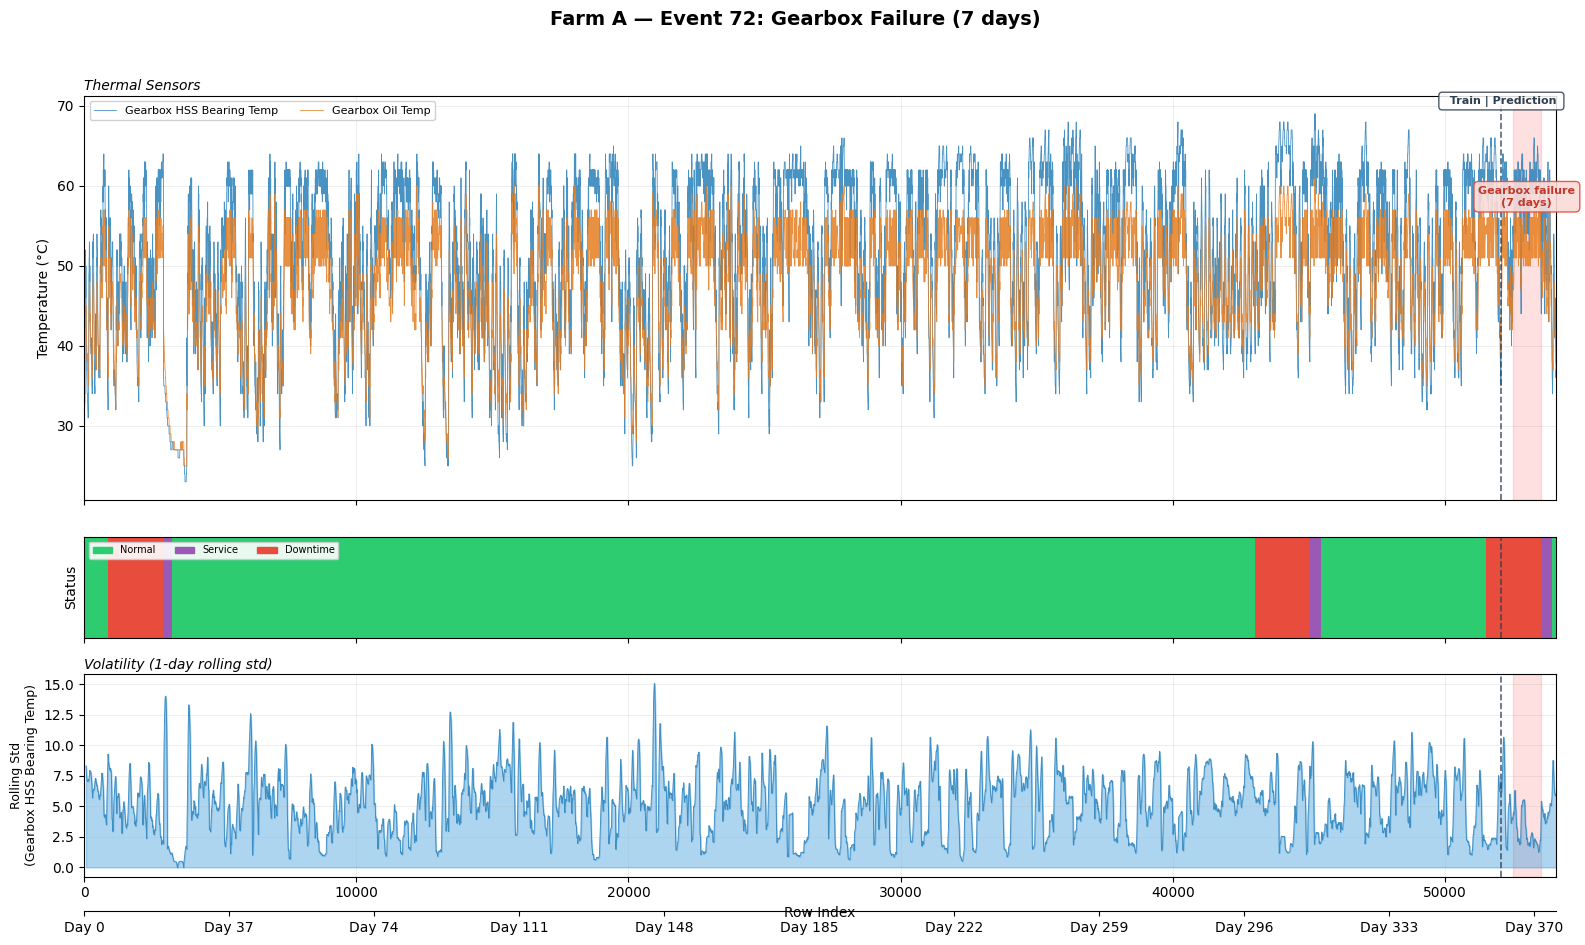

In [3]:
# --- Farm A, Event 72: Gearbox Failure ---
# Gearbox sensors: sensor_11_avg (HSS bearing), sensor_12_avg (oil temp)
fig_a72 = plot_event_timeline(
    farm="A", event_id=72,
    sensors=["sensor_11_avg", "sensor_12_avg"],
    title="Farm A — Event 72: Gearbox Failure (7 days)",
    save_path=os.path.join(PROJECT_ROOT, "outputs", "figures", "timeline_farm_a_event72_gearbox.png"),
)

  Saved: D:\Personal Projects\Enbridge Case Compettion\outputs\figures\timeline_farm_a_event0_gen_bearing.png


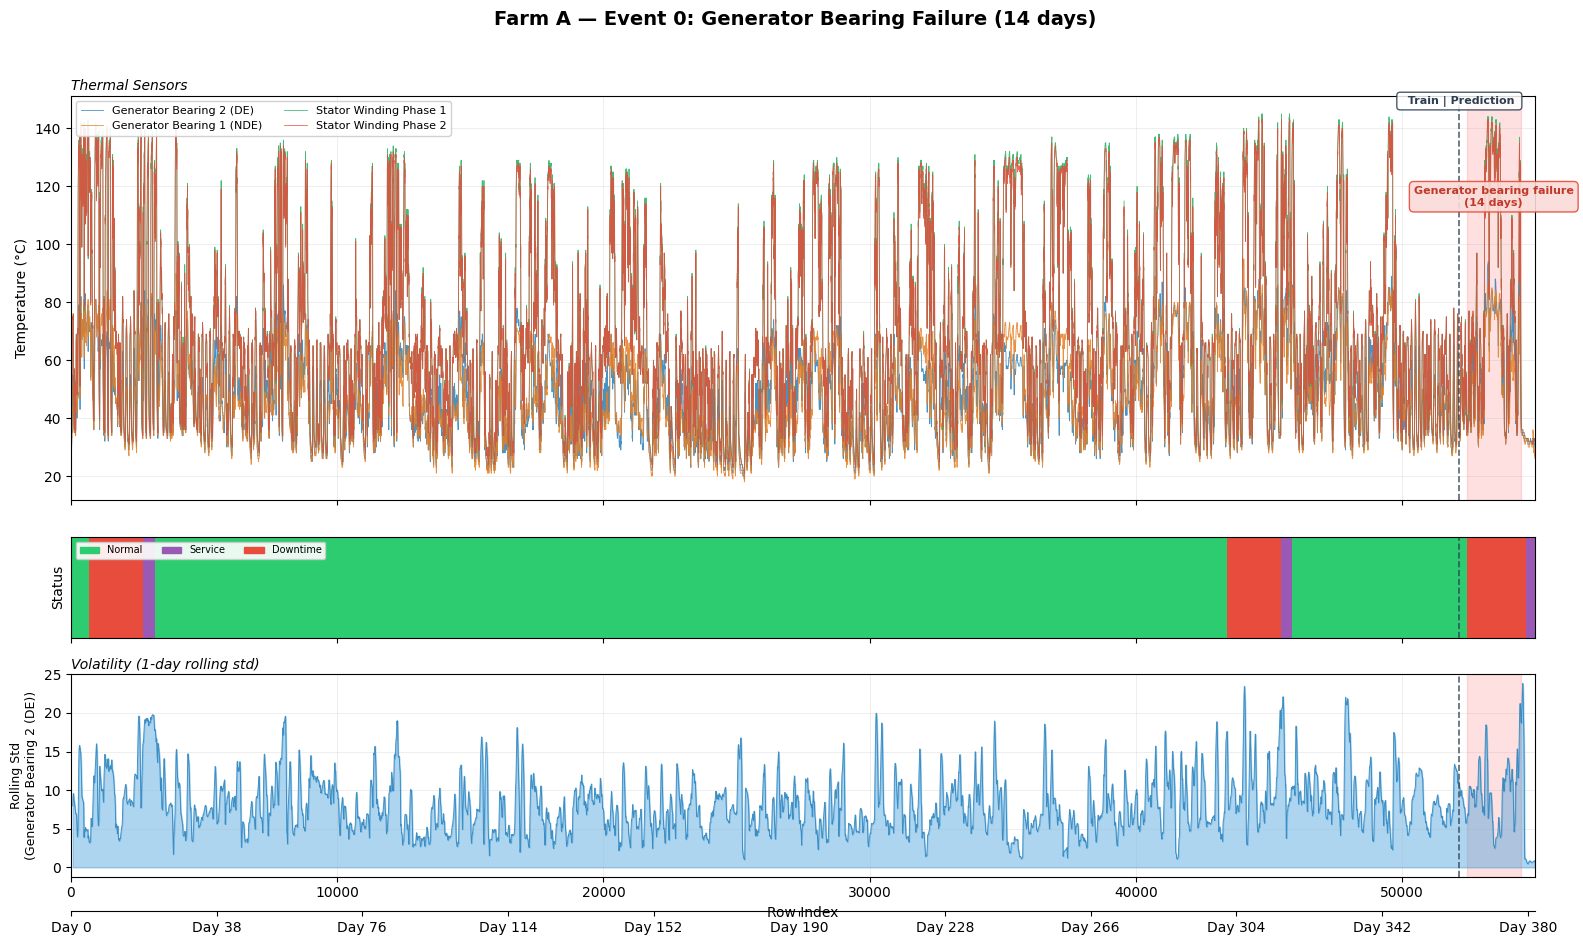

In [4]:
# --- Farm A, Event 0: Generator Bearing Failure ---
# Generator bearing sensors: sensor_13 (DE), sensor_14 (NDE), sensor_15/16/17 (stator windings)
fig_a0 = plot_event_timeline(
    farm="A", event_id=0,
    sensors=["sensor_13_avg", "sensor_14_avg", "sensor_15_avg", "sensor_16_avg"],
    title="Farm A — Event 0: Generator Bearing Failure (14 days)",
    save_path=os.path.join(PROJECT_ROOT, "outputs", "figures", "timeline_farm_a_event0_gen_bearing.png"),
)

  Saved: D:\Personal Projects\Enbridge Case Compettion\outputs\figures\timeline_farm_a_event68_transformer.png


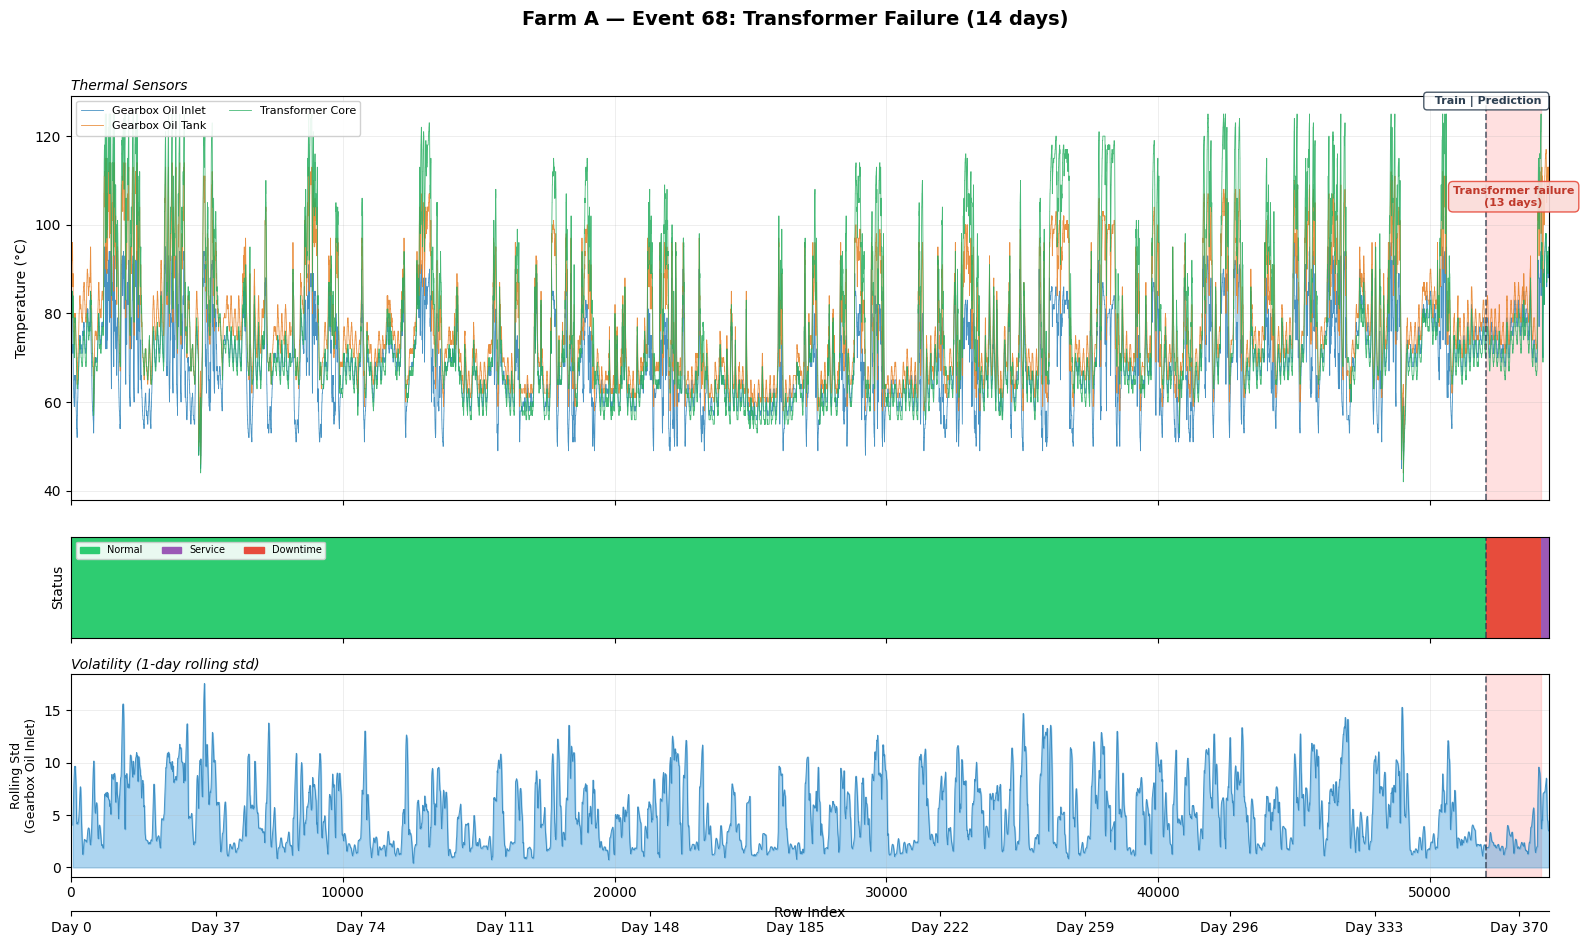

In [5]:
# --- Farm A, Event 68: Transformer Failure ---
# Transformer sensors: sensor_38 (L1), sensor_39 (L2), sensor_40 (L3)
fig_a68 = plot_event_timeline(
    farm="A", event_id=68,
    sensors=["sensor_38_avg", "sensor_39_avg", "sensor_40_avg"],
    title="Farm A — Event 68: Transformer Failure (14 days)",
    save_path=os.path.join(PROJECT_ROOT, "outputs", "figures", "timeline_farm_a_event68_transformer.png"),
)

## Farm B — Bearing Degradation Timeline

Farm B has 257 features and 6 anomaly events. The standout is Event 53 — a 42-day rotor bearing damage event that should show gradual status changes and slow temperature drift, making it a classic example of progressive mechanical degradation.

  Saved: D:\Personal Projects\Enbridge Case Compettion\outputs\figures\timeline_farm_b_event53_bearing.png


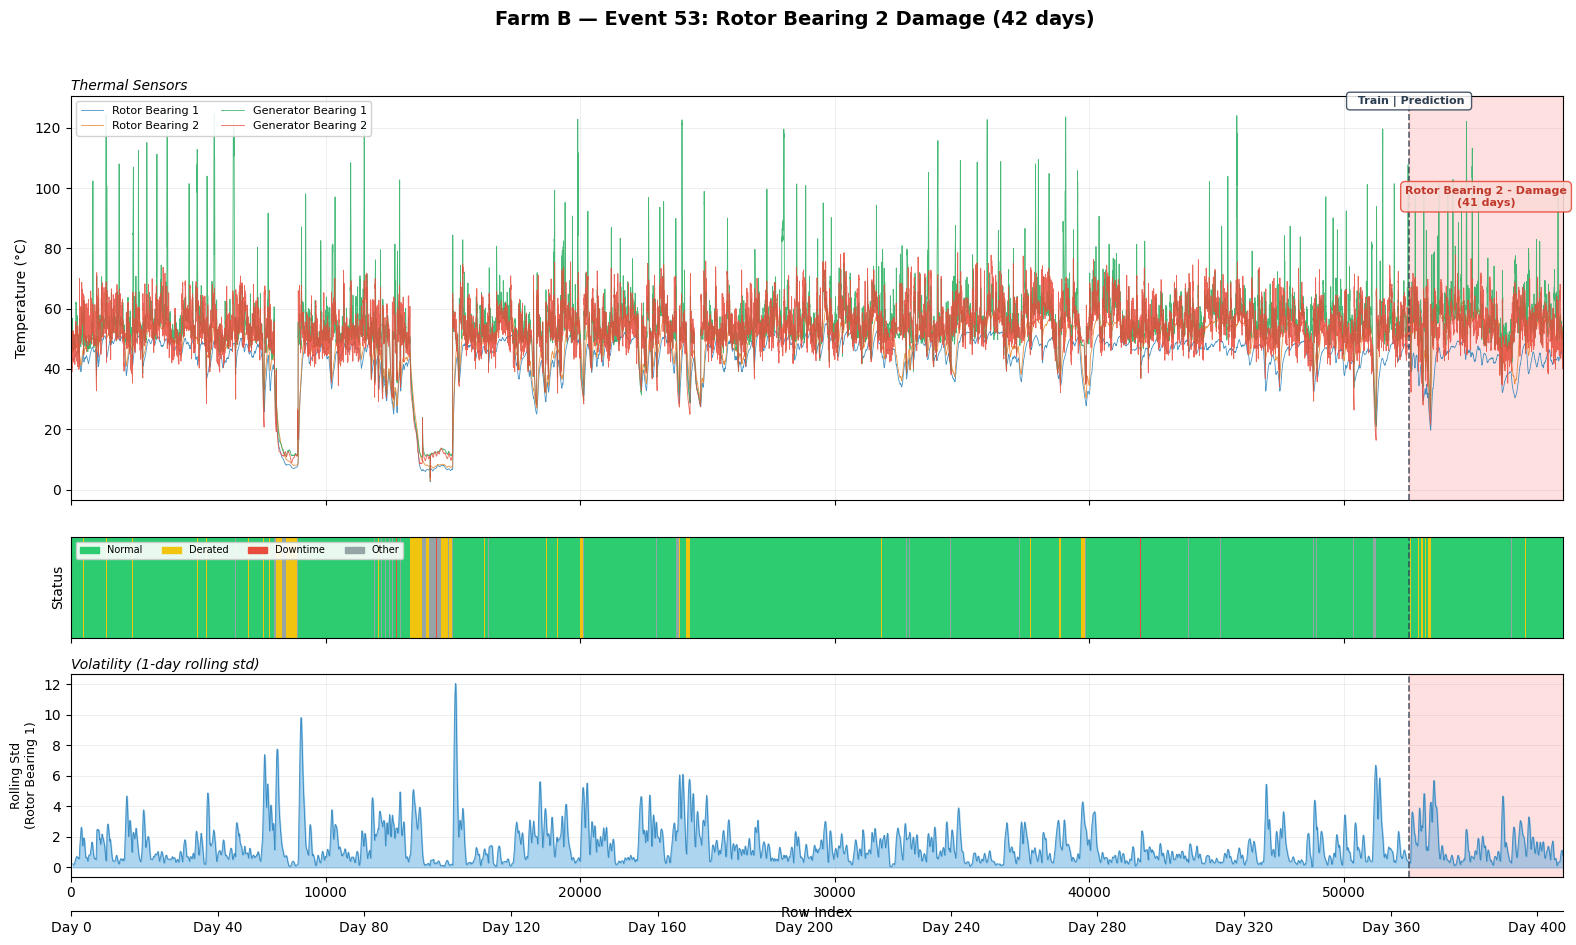

In [6]:
# --- Farm B, Event 53: Rotor Bearing 2 Damage ---
# Bearing sensors: sensor_51 (Rotor Bearing 1), sensor_52 (Rotor Bearing 2), 
#                  sensor_32 (Gen Bearing 1), sensor_33 (Gen Bearing 2)
# This 42-day event should show gradual status changes and slow temp drift
fig_b53 = plot_event_timeline(
    farm="B", event_id=53,
    sensors=["sensor_51_avg", "sensor_52_avg", "sensor_32_avg", "sensor_33_avg"],
    title="Farm B — Event 53: Rotor Bearing 2 Damage (42 days)",
    save_path=os.path.join(PROJECT_ROOT, "outputs", "figures", "timeline_farm_b_event53_bearing.png"),
)

  Saved: D:\Personal Projects\Enbridge Case Compettion\outputs\figures\timeline_farm_b_event34_transformer.png


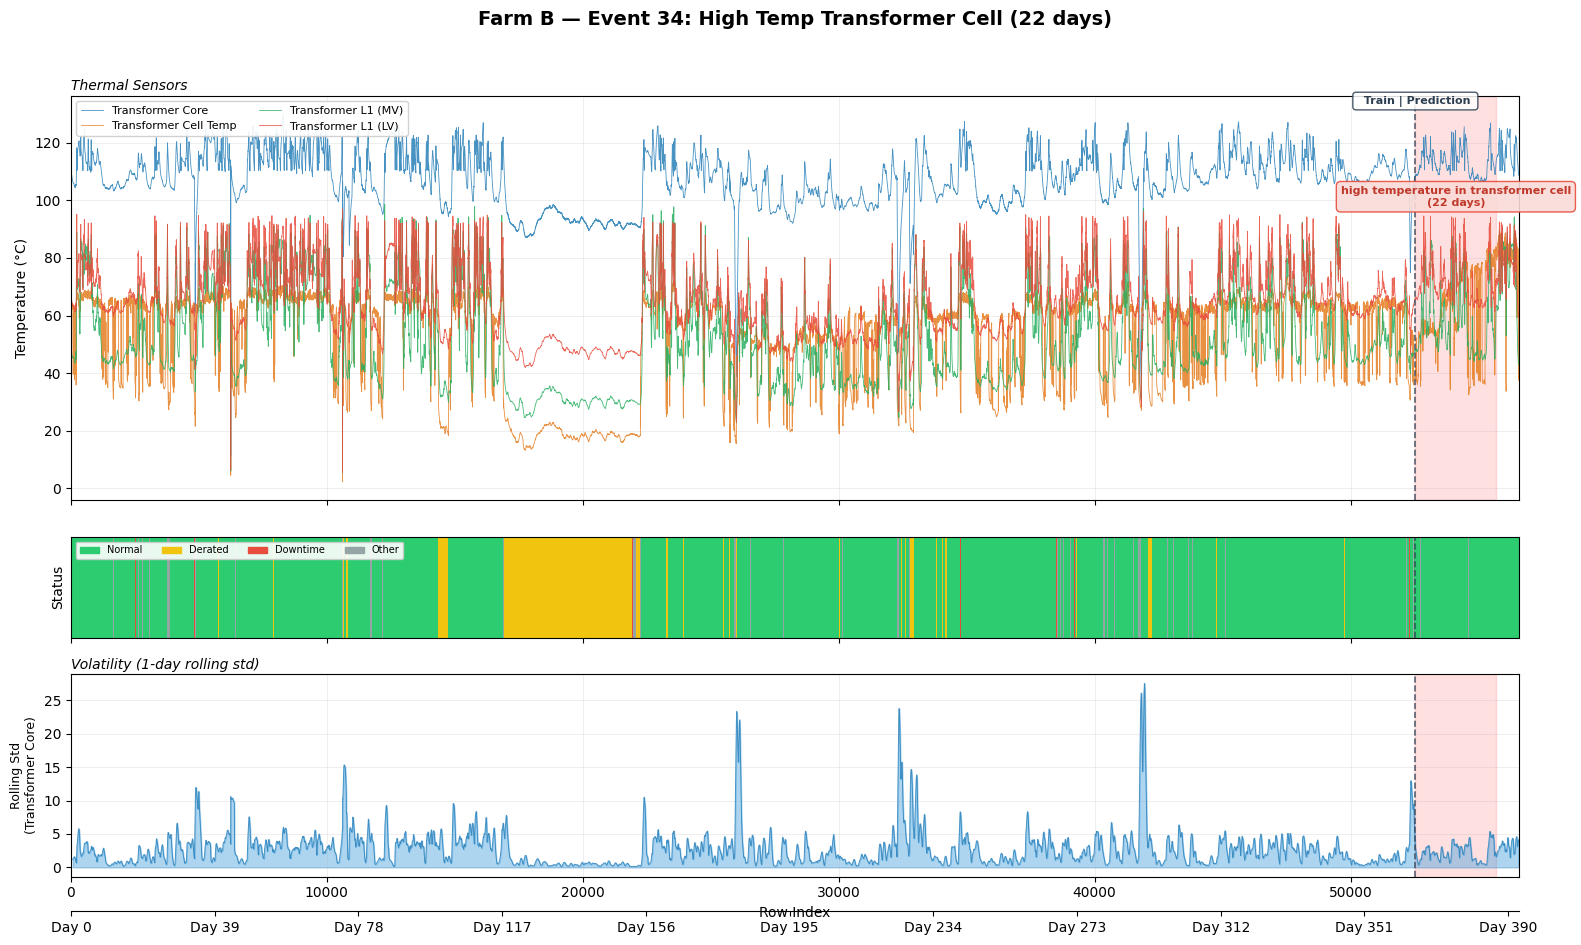

In [7]:
# --- Farm B, Event 34: High Temperature Transformer Cell ---
# Transformer sensors: sensor_40 (core), sensor_41/42 (L1 MV/LV), sensor_47 (cell temp)
fig_b34 = plot_event_timeline(
    farm="B", event_id=34,
    sensors=["sensor_40_avg", "sensor_47_avg", "sensor_41_avg", "sensor_42_avg"],
    title="Farm B — Event 34: High Temp Transformer Cell (22 days)",
    save_path=os.path.join(PROJECT_ROOT, "outputs", "figures", "timeline_farm_b_event34_transformer.png"),
)

## Farm C — Diverse Fault Timelines

Farm C is the most complex farm with 957 features and 27 anomaly events covering hydraulic, cooling, transformer, pitch, and communication faults. We pick three thermally relevant events that our TDI model needs to detect.

  Saved: D:\Personal Projects\Enbridge Case Compettion\outputs\figures\timeline_farm_c_event47_hydraulic.png


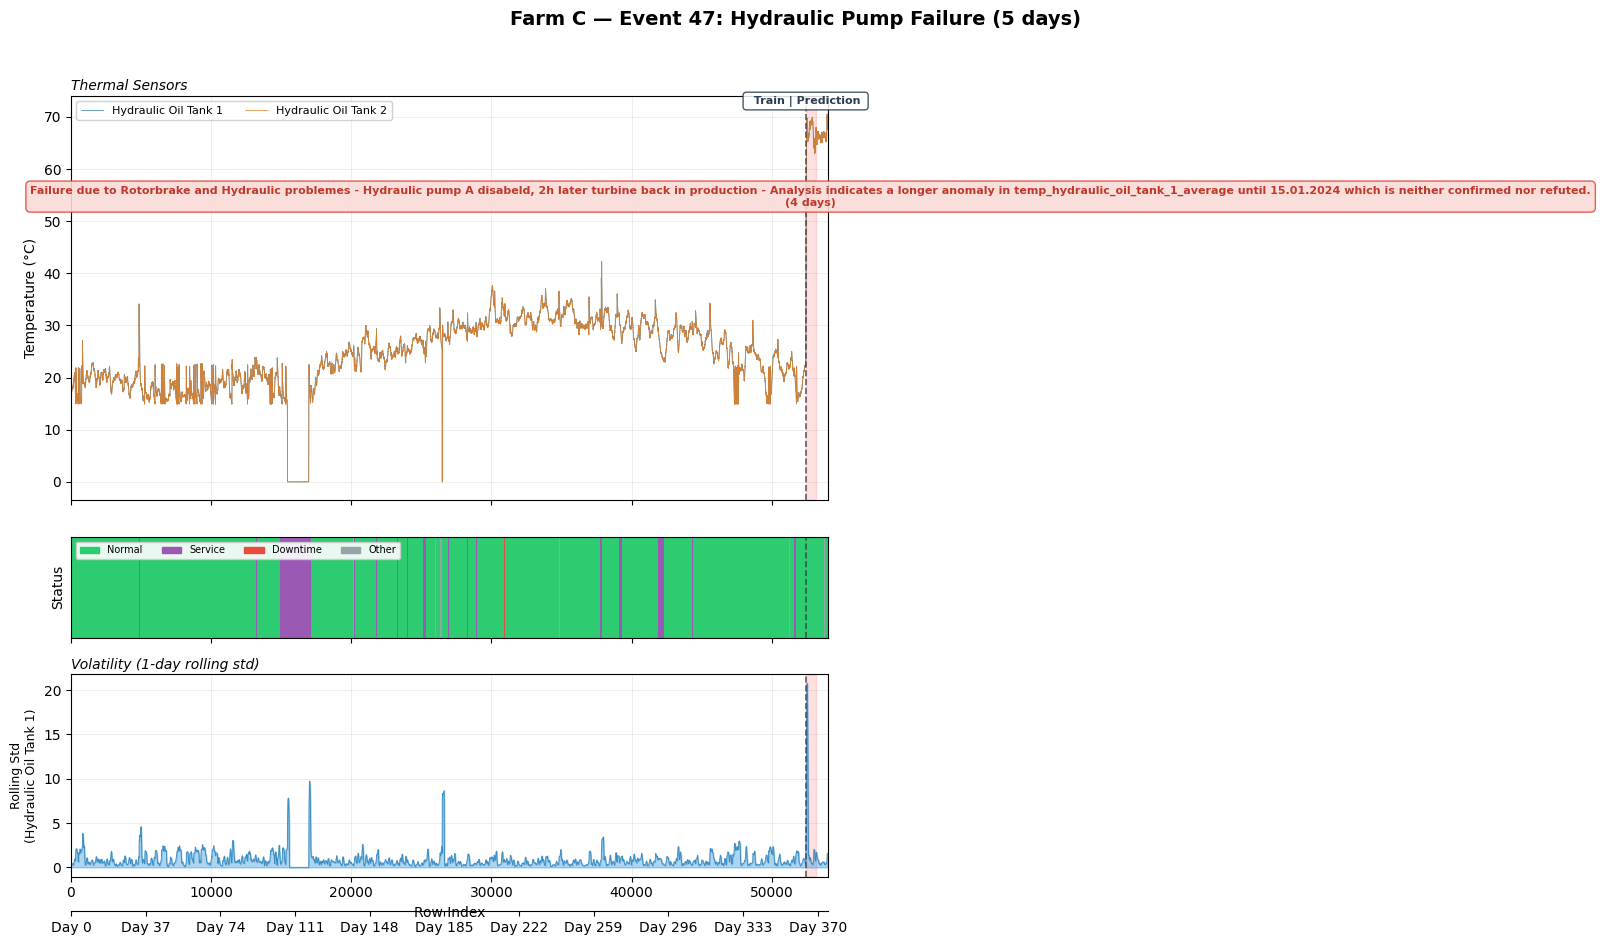

In [8]:
# --- Farm C, Event 47: Hydraulic Pump Failure ---
# Hydraulic sensors: sensor_178 (oil tank 1), sensor_179 (oil tank 2)
fig_c47 = plot_event_timeline(
    farm="C", event_id=47,
    sensors=["sensor_178_avg", "sensor_179_avg"],
    title="Farm C — Event 47: Hydraulic Pump Failure (5 days)",
    save_path=os.path.join(PROJECT_ROOT, "outputs", "figures", "timeline_farm_c_event47_hydraulic.png"),
)

  Saved: D:\Personal Projects\Enbridge Case Compettion\outputs\figures\timeline_farm_c_event44_cooling.png


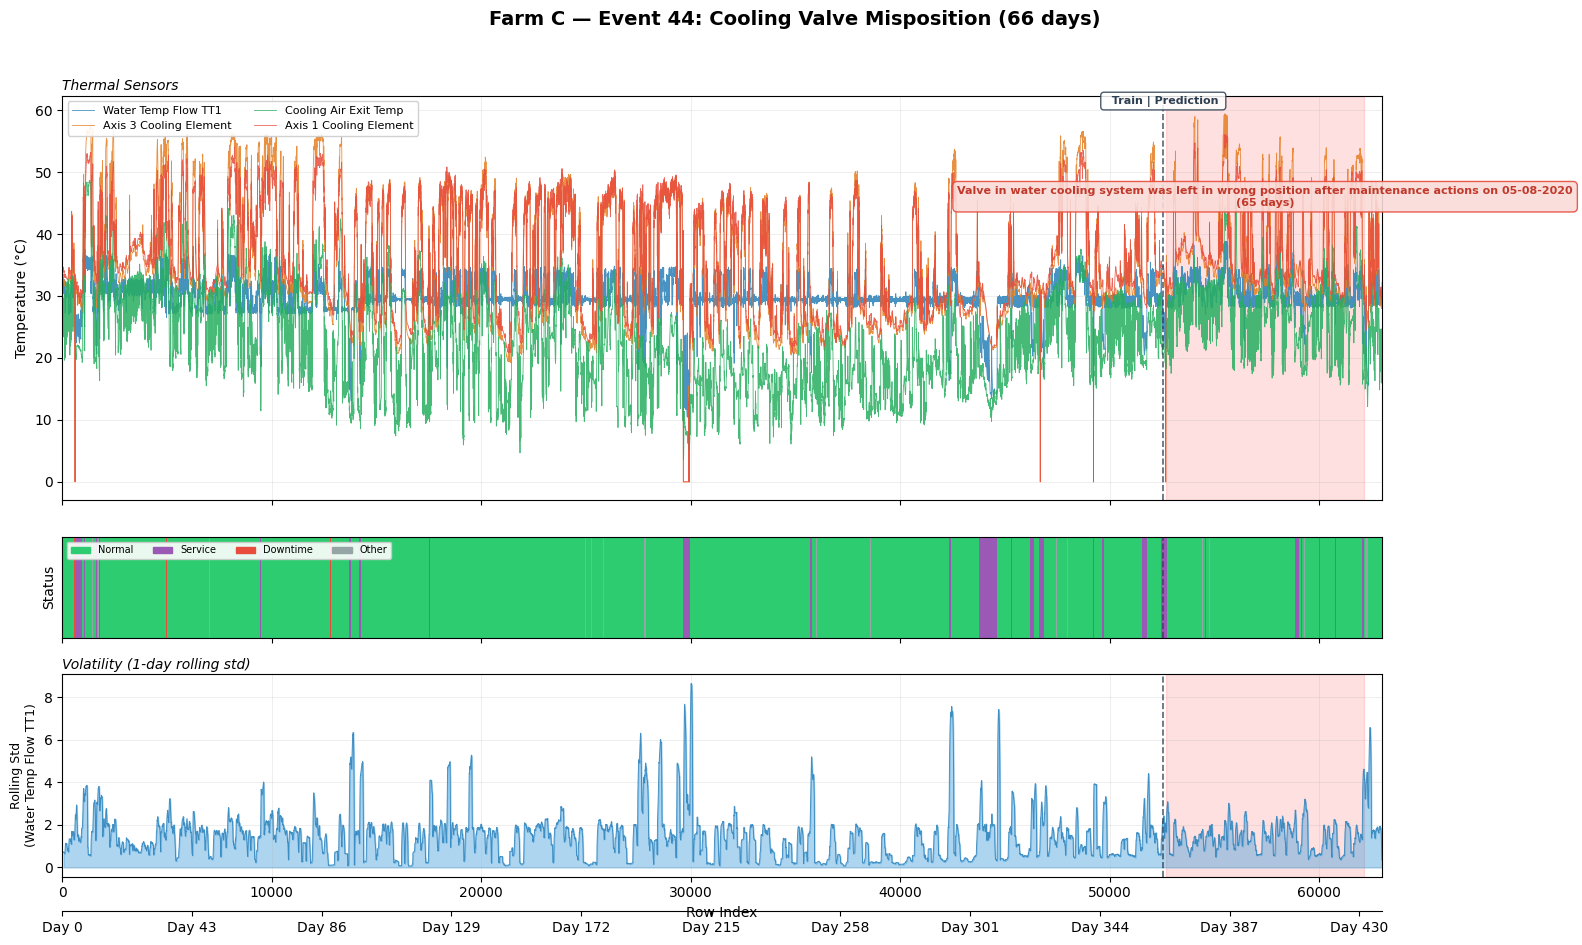

In [9]:
# --- Farm C, Event 44: Cooling Valve Misposition ---
# Cooling sensors: sensor_46 (water temp flow), sensor_175 (axis 3 cooling), 
#                  sensor_176 (cooling air exit), sensor_208 (axis 1 cooling)
fig_c44 = plot_event_timeline(
    farm="C", event_id=44,
    sensors=["sensor_46_avg", "sensor_175_avg", "sensor_176_avg", "sensor_208_avg"],
    title="Farm C — Event 44: Cooling Valve Misposition (66 days)",
    save_path=os.path.join(PROJECT_ROOT, "outputs", "figures", "timeline_farm_c_event44_cooling.png"),
)

  Saved: D:\Personal Projects\Enbridge Case Compettion\outputs\figures\timeline_farm_c_event67_transformer.png


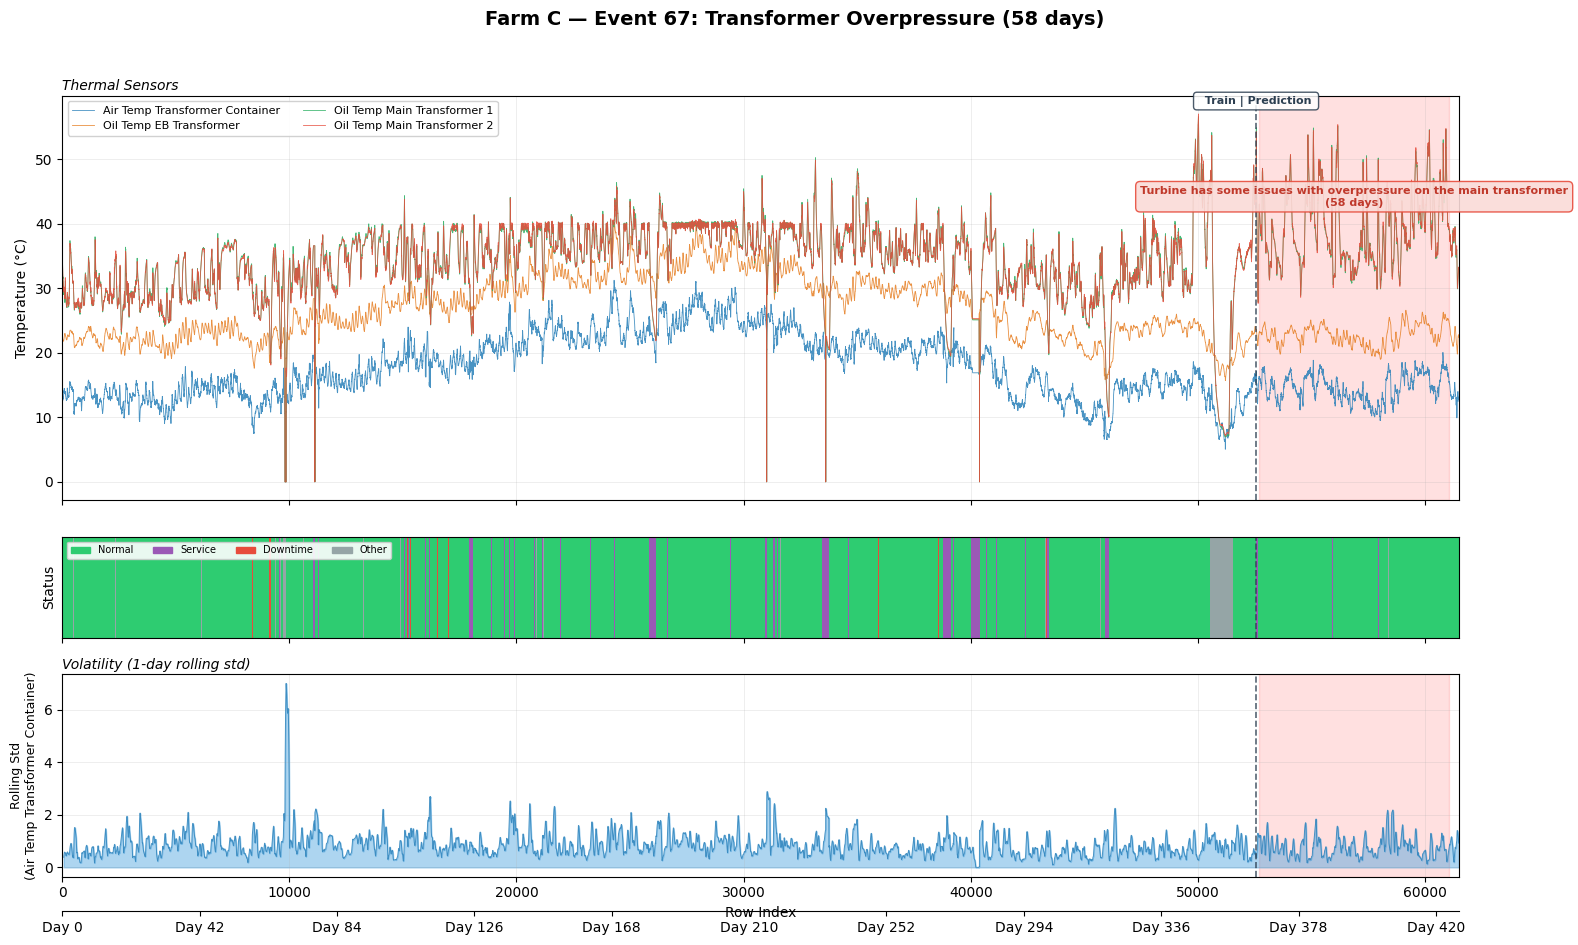

In [10]:
# --- Farm C, Event 67: Transformer Overpressure ---
# Transformer sensors: sensor_167 (air temp xfmr container), sensor_188 (oil temp EB xfmr),
#                       sensor_191 (oil temp main xfmr 1), sensor_192 (oil temp main xfmr 2)
fig_c67 = plot_event_timeline(
    farm="C", event_id=67,
    sensors=["sensor_167_avg", "sensor_188_avg", "sensor_191_avg", "sensor_192_avg"],
    title="Farm C — Event 67: Transformer Overpressure (58 days)",
    save_path=os.path.join(PROJECT_ROOT, "outputs", "figures", "timeline_farm_c_event67_transformer.png"),
)

## Event Duration Analysis

How long do anomaly events last across the fleet? This matters because our detection algorithm needs to catch everything from 2-day electrical faults to 66-day slow degradation events. The bar chart below shows the full range of lead times we need to detect.

Total anomaly events: 45
Duration range: 1.7 — 65.5 days
Median duration: 14.0 days
Mean duration: 17.5 days



Saved: D:\Personal Projects\Enbridge Case Compettion\outputs\figures\event_duration_barchart.png


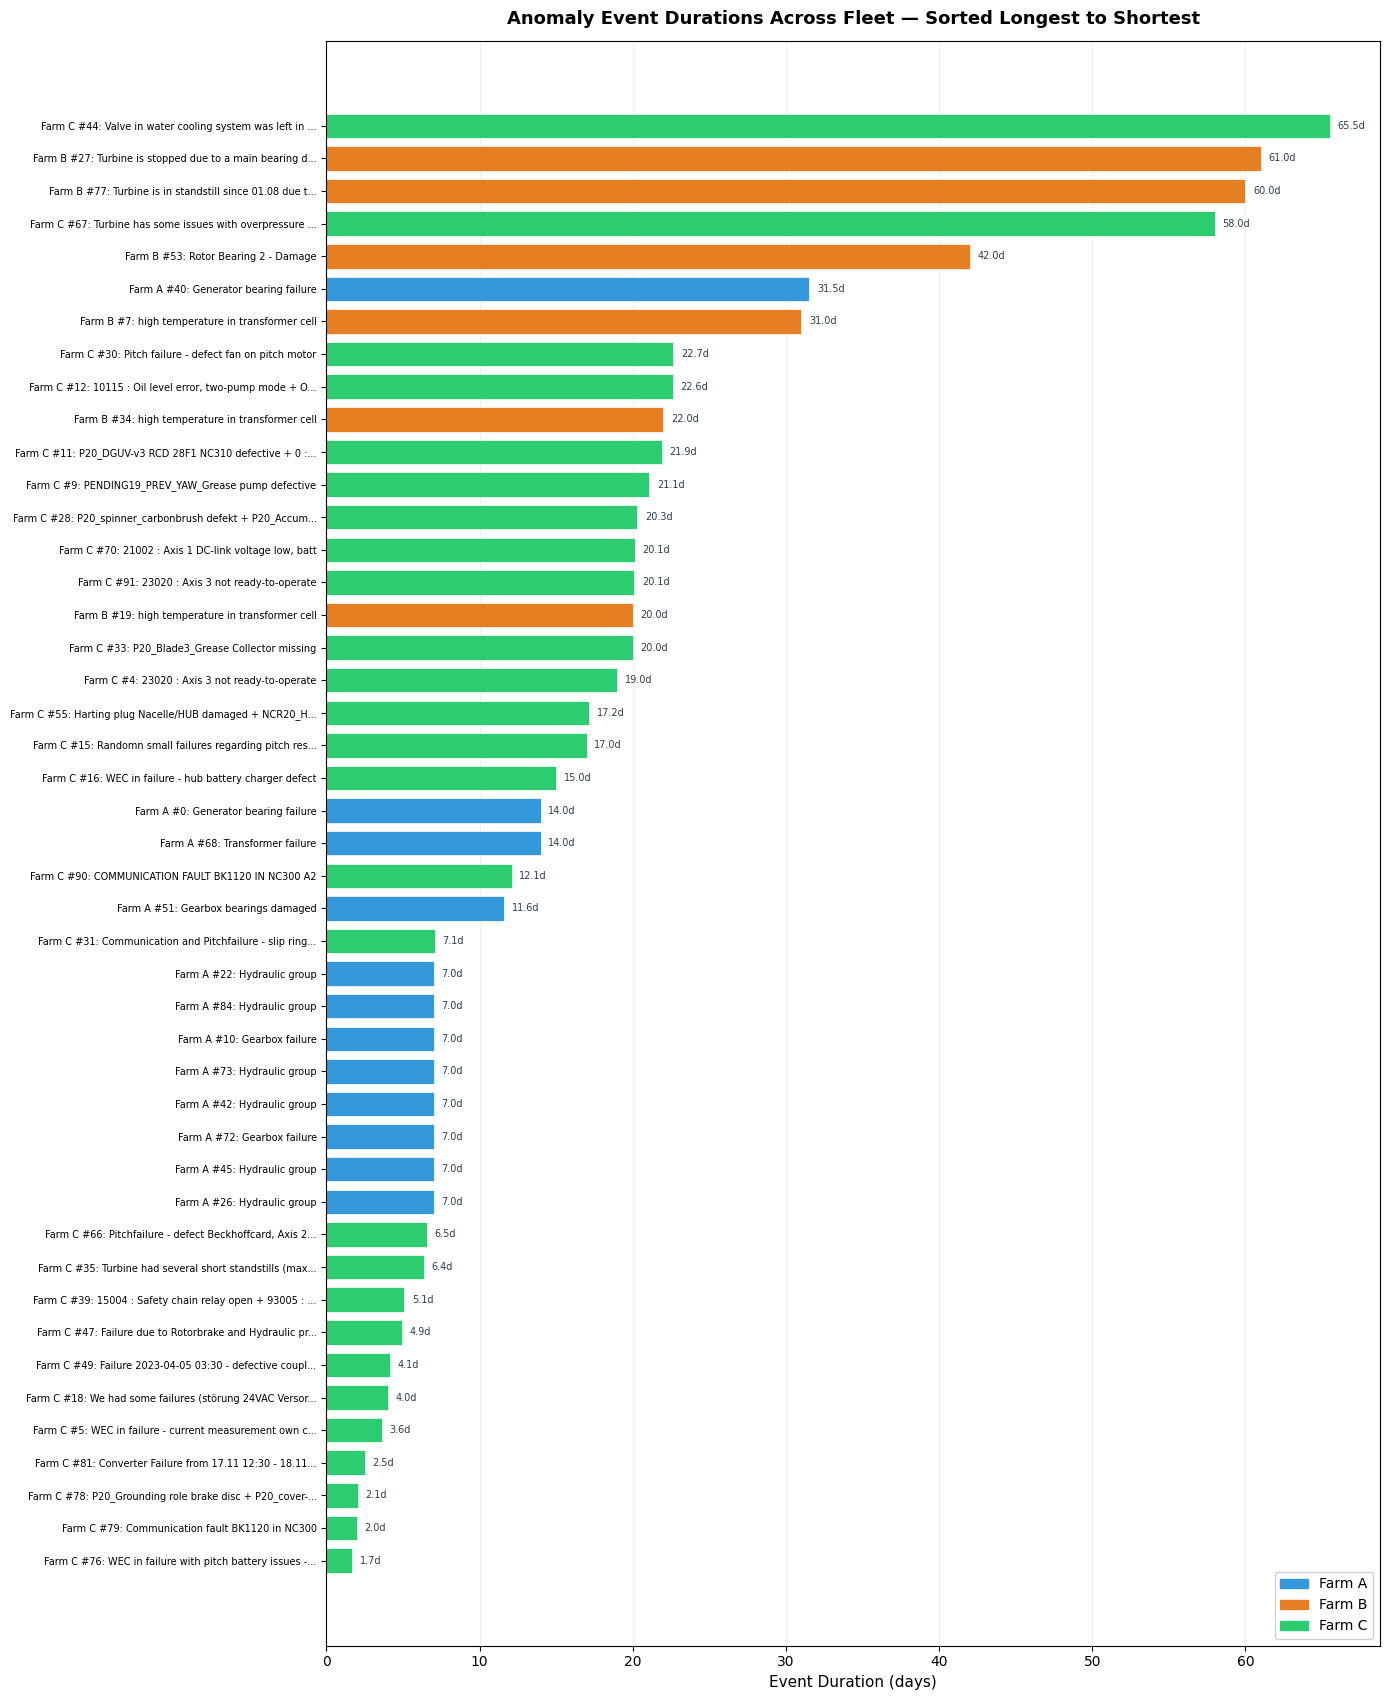

In [11]:
# ---------------------------------------------------------------------------
# Event Duration Bar Chart — all anomaly events, colored by farm
# ---------------------------------------------------------------------------

anomaly_events = event_info[event_info["event_label"] == "anomaly"].copy()
anomaly_events["event_start_dt"] = pd.to_datetime(anomaly_events["event_start"])
anomaly_events["event_end_dt"] = pd.to_datetime(anomaly_events["event_end"])
anomaly_events["duration_days"] = (anomaly_events["event_end_dt"] - anomaly_events["event_start_dt"]).dt.total_seconds() / 86400

# Sort longest to shortest
anomaly_events = anomaly_events.sort_values("duration_days", ascending=True).reset_index(drop=True)

# Truncate long descriptions for bar labels
def short_desc(desc, max_len=45):
    if len(desc) <= max_len:
        return desc
    return desc[:max_len-3] + "..."

anomaly_events["short_desc"] = anomaly_events["event_description"].apply(short_desc)
anomaly_events["bar_label"] = (
    "Farm " + anomaly_events["farm"] + " #" + anomaly_events["event_id"].astype(str) 
    + ": " + anomaly_events["short_desc"]
)

# Farm colors
farm_colors = {"A": "#3498db", "B": "#e67e22", "C": "#2ecc71"}

fig, ax = plt.subplots(figsize=(14, max(8, len(anomaly_events) * 0.38)))

bars = ax.barh(
    range(len(anomaly_events)),
    anomaly_events["duration_days"],
    color=[farm_colors[f] for f in anomaly_events["farm"]],
    edgecolor="white",
    linewidth=0.5,
    height=0.75,
)

# Labels on bars
for i, (_, row) in enumerate(anomaly_events.iterrows()):
    duration = row["duration_days"]
    ax.text(duration + 0.5, i, f"{duration:.1f}d", va="center", fontsize=7, color="#2c3e50")

ax.set_yticks(range(len(anomaly_events)))
ax.set_yticklabels(anomaly_events["bar_label"], fontsize=7)
ax.set_xlabel("Event Duration (days)", fontsize=11)
ax.set_title("Anomaly Event Durations Across Fleet — Sorted Longest to Shortest", 
             fontsize=13, fontweight="bold", pad=12)
ax.grid(axis="x", alpha=0.3, linewidth=0.5)
ax.set_axisbelow(True)

# Farm legend
farm_patches = [mpatches.Patch(color=farm_colors[f], label=f"Farm {f}") for f in ["A", "B", "C"]]
ax.legend(handles=farm_patches, loc="lower right", fontsize=10, framealpha=0.9)

# Summary stats
print(f"Total anomaly events: {len(anomaly_events)}")
print(f"Duration range: {anomaly_events['duration_days'].min():.1f} — {anomaly_events['duration_days'].max():.1f} days")
print(f"Median duration: {anomaly_events['duration_days'].median():.1f} days")
print(f"Mean duration: {anomaly_events['duration_days'].mean():.1f} days")

plt.tight_layout()

save_path = os.path.join(PROJECT_ROOT, "outputs", "figures", "event_duration_barchart.png")
fig.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="white")
print(f"\nSaved: {save_path}")
plt.show()

In [12]:
# ---------------------------------------------------------------------------
# Summary of all saved figures
# ---------------------------------------------------------------------------
import glob

fig_dir = os.path.join(PROJECT_ROOT, "outputs", "figures")
timeline_figs = sorted(glob.glob(os.path.join(fig_dir, "timeline_*.png")))
duration_fig = os.path.join(fig_dir, "event_duration_barchart.png")

print("=== Saved Figures ===")
for f in timeline_figs:
    print(f"  {os.path.basename(f)}")
if os.path.exists(duration_fig):
    print(f"  {os.path.basename(duration_fig)}")
print(f"\nTotal: {len(timeline_figs) + 1} figures in {fig_dir}")

=== Saved Figures ===
  timeline_farm_a_event0_gen_bearing.png
  timeline_farm_a_event68_transformer.png
  timeline_farm_a_event72_gearbox.png
  timeline_farm_b_event34_transformer.png
  timeline_farm_b_event53_bearing.png
  timeline_farm_c_event44_cooling.png
  timeline_farm_c_event47_hydraulic.png
  timeline_farm_c_event67_transformer.png
  event_duration_barchart.png

Total: 9 figures in D:\Personal Projects\Enbridge Case Compettion\outputs\figures


## Key Observations

**Status transitions are the ground truth:**
- The colored status strip clearly shows when the turbine transitions from Normal (green) through Service (purple) to Downtime (red). This is the physical manifestation of each fault that our TDI model needs to predict *before* it happens.

**Event duration varies widely:**
- Shortest events are ~2 days (electrical/communication faults) while longest are 60+ days (slow mechanical degradation like cooling valve misposition). Our detection thresholds need to handle both.

**Temperature precursors:**
- In gearbox and bearing failures, temperature drift often begins *before* the event window — the rolling std panel helps visualize when volatility starts increasing.
- Transformer events sometimes show abrupt temperature spikes rather than gradual drift.

**Train/prediction split matters:**
- The event window always falls within the prediction period. The training period establishes the "normal" baseline that our Normal Behavior Models will learn from.

**Farm complexity scales:**
- Farm A events are cleanest (fewer sensors, clearer signals). Farm C events are noisier with more confounding factors — our model needs to be robust to this.

**Next steps:**
- These timelines inform threshold selection in Phase 4 (CUSUM/EWMA calibration)
- The event duration distribution informs the minimum detection window for our TDI score
- Status transitions will serve as validation targets for anomaly detection accuracy